# California Housing — Random Forest Regressor
## Financial Assistant Project | Regression Model

This notebook trains a **Random Forest Regressor** on the California Housing dataset from scikit-learn.  
The goal is to predict the **median house value** for a district based on demographic and geographic features.

### Steps covered:
1. Load dataset  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing — feature/target split, train/test split, normalization  
4. Model training  
5. Evaluation — RMSE, MAE, R²  
6. Save model artifacts  
7. Inference function for SageMaker


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset shape: {df.shape}")
print(f"\nFeature descriptions:")
for name, desc in zip(housing.feature_names, housing.DESCR.split('\n')[15:23]):
    print(f"  {name}: {desc.strip()}")
df.head()

Dataset shape: (20640, 9)

Feature descriptions:
  MedInc: - AveBedrms     average number of bedrooms
  HouseAge: - Population    block population
  AveRooms: - AveOccup      average house occupancy
  AveBedrms: - Latitude      house block latitude
  Population: - Longitude     house block longitude
  AveOccup: 
  Latitude: :Missing Attribute Values: None
  Longitude: 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis

In [3]:
# Basic statistics
print("=== Basic Statistics ===")
display(df.describe())

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Target column: MedHouseVal (median house value in $100,000s)")

=== Basic Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Missing values: 0
Target column: MedHouseVal (median house value in $100,000s)


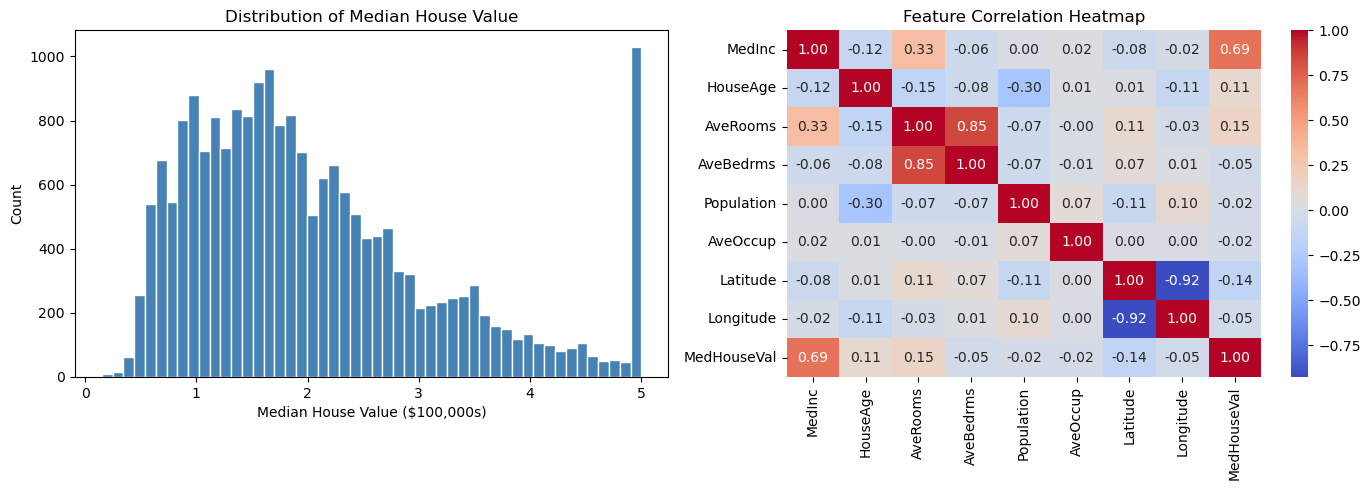

Key insight: MedInc (median income) has the strongest correlation with house value (0.69)


In [4]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Count')

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Key insight: MedInc (median income) has the strongest correlation with house value (0.69)")

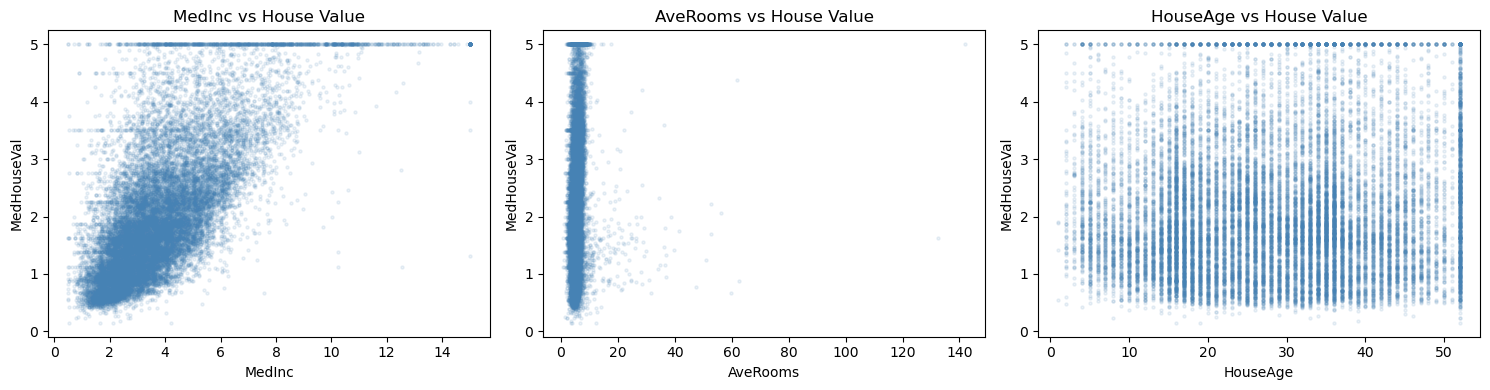

In [5]:
# Scatter plots of top features vs target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
top_features = ['MedInc', 'AveRooms', 'HouseAge']

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [6]:
# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape : (20640, 8)
Target shape   : (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [7]:
# Train / test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 16512
Test samples     : 4128


In [8]:
# Normalize features using StandardScaler
# IMPORTANT: fit only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only

print("Before scaling (train):")
print(f"  Mean MedInc: {X_train['MedInc'].mean():.3f}")
print(f"  Std  MedInc: {X_train['MedInc'].std():.3f}")
print("\nAfter scaling (train):")
print(f"  Mean MedInc: {X_train_scaled[:, 0].mean():.3f}")
print(f"  Std  MedInc: {X_train_scaled[:, 0].std():.3f}")

Before scaling (train):
  Mean MedInc: 3.881
  Std  MedInc: 1.904

After scaling (train):
  Mean MedInc: -0.000
  Std  MedInc: 1.000


## 5. Train Model

In [9]:
model = RandomForestRegressor(
    n_estimators=100,    # number of trees
    max_depth=None,      # grow trees fully
    min_samples_split=2,
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

print("Training Random Forest Regressor...")
model.fit(X_train_scaled, y_train)
print(f"Training complete. Trees in forest: {len(model.estimators_)}")

Training Random Forest Regressor...
Training complete. Trees in forest: 100


## 6. Evaluate Model

In [10]:
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       Evaluation Metrics")
print("=" * 40)
print(f"  RMSE  : {rmse:.4f}  (${rmse*100_000:,.0f} avg error)")
print(f"  MAE   : {mae:.4f}  (${mae*100_000:,.0f} avg error)")
print(f"  R²    : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print("=" * 40)

       Evaluation Metrics
  RMSE  : 0.5065  ($50,654 avg error)
  MAE   : 0.3281  ($32,809 avg error)
  R²    : 0.8042  (80.4% variance explained)


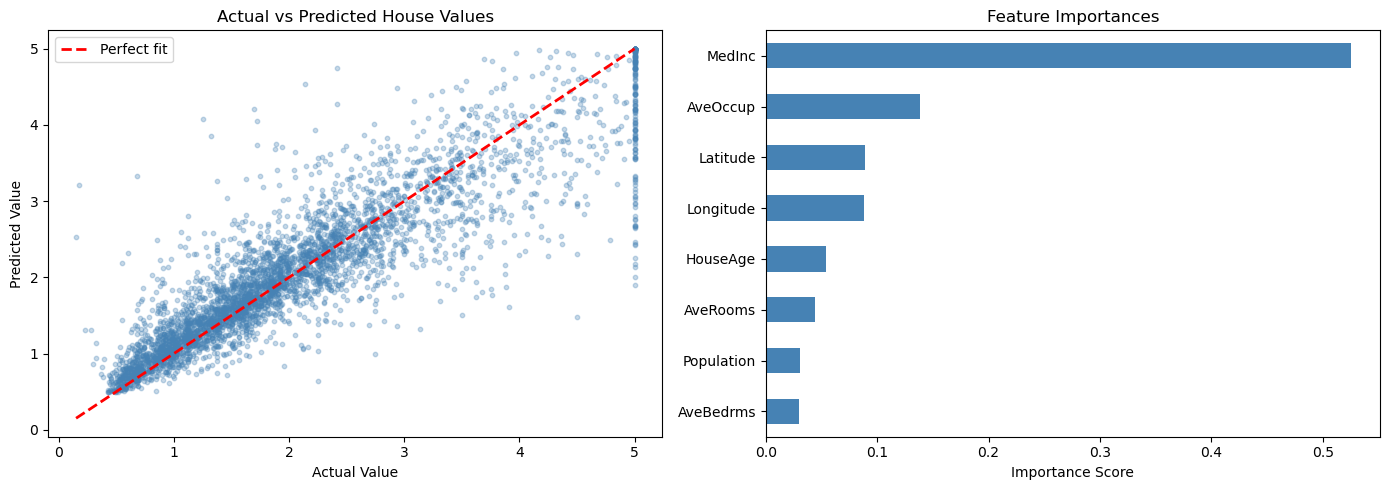

In [11]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Actual vs Predicted House Values')
axes[0].legend()

# Feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

## 7. Save Model Artifacts

In [12]:
os.makedirs('model_artifacts', exist_ok=True)
joblib.dump(model,  'model_artifacts/rf_regressor.joblib')
joblib.dump(scaler, 'model_artifacts/scaler_regression.joblib')

print("Saved:")
print("  model_artifacts/rf_regressor.joblib")
print("  model_artifacts/scaler_regression.joblib")

Saved:
  model_artifacts/rf_regressor.joblib
  model_artifacts/scaler_regression.joblib


## 8. Inference Function (SageMaker)
This function is what the SageMaker endpoint will call when it receives a prediction request.


In [13]:
def predict_house_value(features: dict) -> float:
    """
    Input : dict with keys MedInc, HouseAge, AveRooms, AveBedrms,
                           Population, AveOccup, Latitude, Longitude
    Output: predicted median house value in $100,000s
    """
    loaded_model  = joblib.load('model_artifacts/rf_regressor.joblib')
    loaded_scaler = joblib.load('model_artifacts/scaler_regression.joblib')
    input_df = pd.DataFrame([features])
    scaled   = loaded_scaler.transform(input_df)
    return round(float(loaded_model.predict(scaled)[0]), 4)

# Test the inference function
sample_input = {
    'MedInc': 8.3252, 'HouseAge': 41.0, 'AveRooms': 6.984,
    'AveBedrms': 1.023, 'Population': 322.0, 'AveOccup': 2.555,
    'Latitude': 37.88, 'Longitude': -122.23
}

result = predict_house_value(sample_input)
print(f"Sample prediction : ${result * 100_000:,.0f}")

Sample prediction : $427,040
